# 06. Гетероскедастичность и WLS

**Проблема из блока 5**: BP p-value ≈ 10⁻²⁹⁵ — гетероскедастичность не убрана через feature engineering. t-тесты и доверительные интервалы в OLS теперь некорректны.

**Метод**: Weighted Least Squares (двухшаговая FGLS, конспект §11):
1. Оцениваем `σ²(x)` через вспомогательную регрессию `ln(e²) ~ X`
2. Веса `w_i = 1/σ̂²(x_i)`
3. WLS — минимизация $\sum w_i (y_i - \hat{y}_i)^2$

WLS — **та же линейная регрессия**, наблюдения с большой дисперсией получают меньший вес. Это даёт корректные SE.


In [1]:
import sys, pathlib, json as _json, pickle
sys.path.insert(0, str(pathlib.Path('.').resolve()))
from helpers import (set_plot_style, load_data, impute_median, make_design,
                     backward_elimination, derived_features, fit_fgls_wls,
                     format_test_row, NUM_COLS_FULL, CAT_FEATURES)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson

set_plot_style()
df, df_train, df_test = load_data()
df_train = impute_median(df_train, NUM_COLS_FULL)
df_train = derived_features(df_train, center=True)
with open('selected_features.json') as fh:
    KEEP = _json.load(fh)['keep']


## 1. Восстановление M_fe_back из блока 5


In [2]:
# Восстанавливаем M_fe_back (блок 5)
fe_num_base = [c for c in KEEP if c not in ('age', 'mileage', 'weight_curb')]
fe_num_base += ['age_c', 'mileage_c', 'ln_weight_curb']
fe_num = fe_num_base + ['hp_per_kg', 'hp_per_liter',
                         'age_c_sq', 'mileage_c_sq', 'ln_mileage',
                         'engine_x_age']
X_fe, _ = make_design(df_train, fe_num, CAT_FEATURES)
X_fe_c  = sm.add_constant(X_fe.astype(float))
y = df_train['price_log1p'].values
m_fe_back, X_fe_back_c, _ = backward_elimination(X_fe_c, y, alpha=0.05)

bp_ols = het_breuschpagan(m_fe_back.resid, X_fe_back_c)
print(f'M_fe_back (OLS): R²={m_fe_back.rsquared:.4f}  BP LM={bp_ols[0]:.0f}  p={bp_ols[1]:.3g}')
print(f'k={len(m_fe_back.params)}')


M_fe_back (OLS): R²=0.8248  BP LM=1482  p=1.62e-287
k=38


## 2. Двухшаговая FGLS — оценка `σ²(x)`


In [3]:
# Шаг 1: вспомогательная регрессия log(e²) на X_fe_back
e2 = np.maximum(m_fe_back.resid ** 2, 1e-10)
log_e2 = np.log(e2)
aux = sm.OLS(log_e2, X_fe_back_c).fit()
sigma2_hat = np.exp(aux.fittedvalues)
weights = 1.0 / sigma2_hat

print(f'Вспомогательная регрессия: R²={aux.rsquared:.4f}')
print(f'σ̂²(x): min={sigma2_hat.min():.4e}  max={sigma2_hat.max():.4e}')
print(f'Веса w_i: min={weights.min():.2e}  max={weights.max():.2e}  ratio={weights.max()/weights.min():.0f}×')


Вспомогательная регрессия: R²=0.0987
σ̂²(x): min=1.0000e-10  max=7.3335e-01
Веса w_i: min=1.36e+00  max=1.00e+10  ratio=7333530272×


## 3. Распределение весов

Большой ratio max/min весов значит, что некоторые наблюдения «штрафуются» сильнее других — это и есть смысл WLS.


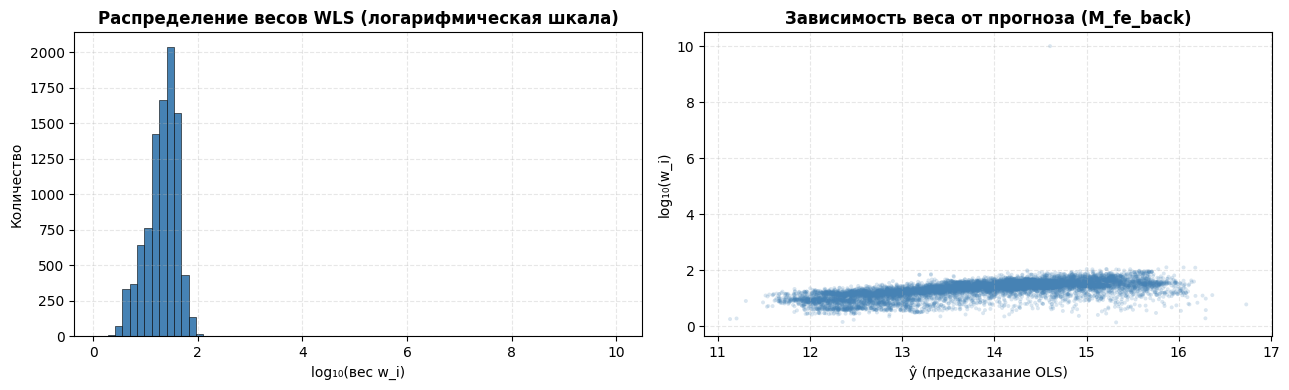

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.log10(weights), bins=70, color='steelblue', edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('log₁₀(вес w_i)'); axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение весов WLS (логарифмическая шкала)')

axes[1].scatter(m_fe_back.fittedvalues, np.log10(weights), alpha=0.2, s=8,
                color='steelblue', edgecolors='none')
axes[1].set_xlabel('ŷ (предсказание OLS)'); axes[1].set_ylabel('log₁₀(w_i)')
axes[1].set_title('Зависимость веса от прогноза (M_fe_back)')
plt.tight_layout(); plt.show()


## 4. Шаг 2: WLS


In [5]:
m_wls = sm.WLS(y, X_fe_back_c, weights=weights).fit()
# BP на взвешенных остатках — проверка успешности коррекции
wresid = m_wls.resid * np.sqrt(weights)
bp_wls = het_breuschpagan(wresid, X_fe_back_c)

print(f'M_fe_back (OLS): BP LM={bp_ols[0]:.0f}     p={bp_ols[1]:.3g}')
print(f'M_wls (wresid):  BP LM={bp_wls[0]:.0f}     p={bp_wls[1]:.3g}')
print(f'  → BP снизился в {bp_ols[0]/bp_wls[0]:.1f}× раз')


M_fe_back (OLS): BP LM=1482     p=1.62e-287
M_wls (wresid):  BP LM=231     p=7e-30
  → BP снизился в 6.4× раз


## 5. Сравнение OLS(M_fe_back) vs WLS(M_fe_back) — все диагностики


In [6]:
def diag(model, X_const, weighted_resid=None):
    if weighted_resid is None:
        weighted_resid = model.resid.values
    try:
        sr = pd.Series(model.get_influence().resid_studentized_internal)\
                 .replace([np.inf,-np.inf], np.nan).dropna().values
    except (AttributeError, NotImplementedError):
        sr = (weighted_resid - np.mean(weighted_resid)) / np.std(weighted_resid)
    jb = stats.jarque_bera(sr)
    bp = het_breuschpagan(weighted_resid, X_const)
    try:
        rt = linear_reset(model, power=2, use_f=True)
        reset_p = float(rt.pvalue)
    except Exception:
        reset_p = float('nan')
    return pd.Series({
        'R²adj':   round(model.rsquared_adj, 4),
        'AIC':     int(round(model.aic)),
        'BIC':     int(round(model.bic)),
        'k':       len(model.params),
        'skew(резид)':  round(float(stats.skew(sr)), 3),
        'kurt(резид)':  round(float(stats.kurtosis(sr, fisher=False)), 3),
        'JB p':    f'{jb[1]:.3g}',
        'BP LM':   int(round(bp[0])),
        'BP p':    f'{bp[1]:.3g}',
        'DW':      round(float(durbin_watson(weighted_resid)), 3),
        'RESET p': f'{reset_p:.3g}' if not np.isnan(reset_p) else 'nan',
    })

diag_ols = diag(m_fe_back, X_fe_back_c, m_fe_back.resid.values)
diag_wls = diag(m_wls, X_fe_back_c, wresid.values if hasattr(wresid,'values') else wresid)
cmp = pd.concat([diag_ols, diag_wls], axis=1)
cmp.columns = ['M_fe_back (OLS)', 'M_wls (взвеш.)']
cmp


/Users/demn/py313-global/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


,M_fe_back (OLS),M_wls (взвеш.)
R²adj,0.8241,0.8708
AIC,13316,10297
BIC,13588,10569
k,38,38
skew(резид),-0.0,-0.269
kurt(резид),6.123,4.664
JB p,0,4.54e-263
BP LM,1482,231
BP p,1.62e-287,7e-30
DW,2.011,2.018


## 6. Сравнение коэффициентов OLS(M_fe_back) vs WLS

WLS даёт **корректные стандартные ошибки**. Сами оценки β̂ могут немного сместиться (это нормально).


In [7]:
# Общие признаки
common = m_fe_back.params.index.intersection(m_wls.params.index)
coef_compare = pd.DataFrame({
    'β OLS':       m_fe_back.params[common].round(4),
    'β WLS':       m_wls.params[common].round(4),
    'Δβ':          (m_wls.params[common] - m_fe_back.params[common]).round(4),
    'SE OLS':      m_fe_back.bse[common].round(4),
    'SE WLS':      m_wls.bse[common].round(4),
    'SE_OLS/SE_WLS': (m_fe_back.bse[common] / m_wls.bse[common]).round(2),
})
num_first = [c for c in common if not c.startswith(('fuel_type','transmission','drive_type','body_type'))]
cat_after = [c for c in common if c not in num_first]
coef_compare = coef_compare.loc[num_first + cat_after].head(20)
print('Сравнение коэффициентов (числовые + первые категории):')
coef_compare


Сравнение коэффициентов (числовые + первые категории):


,β OLS,β WLS,Δβ,SE OLS,SE WLS,SE_OLS/SE_WLS
const,6.1730,6.2734,0.1004,0.4743,0.3996,1.19
rear_track_width,0.0016,0.0014,-0.0002,0.0001,0.0001,1.21
max_torque_nm,-0.0006,-0.0009,-0.0003,0.0001,0.0001,1.38
gears_count,0.0317,0.0237,-0.0080,0.0066,0.0046,1.43
wheelbase,0.0003,0.0005,0.0002,0.0001,0.0001,1.14
acceleration_0_100,-0.0273,-0.0361,-0.0088,0.0028,0.0028,1.02
valves_per_cylinder,0.0695,0.0801,0.0106,0.0098,0.0093,1.06
tax_amount,0.0000,0.0000,0.0000,0.0000,0.0000,1.17
owners_count,-0.0576,-0.0468,0.0108,0.0060,0.0051,1.19
engine_volume,0.0587,0.0939,0.0352,0.0249,0.0211,1.18


## 7. Графики остатков OLS vs WLS


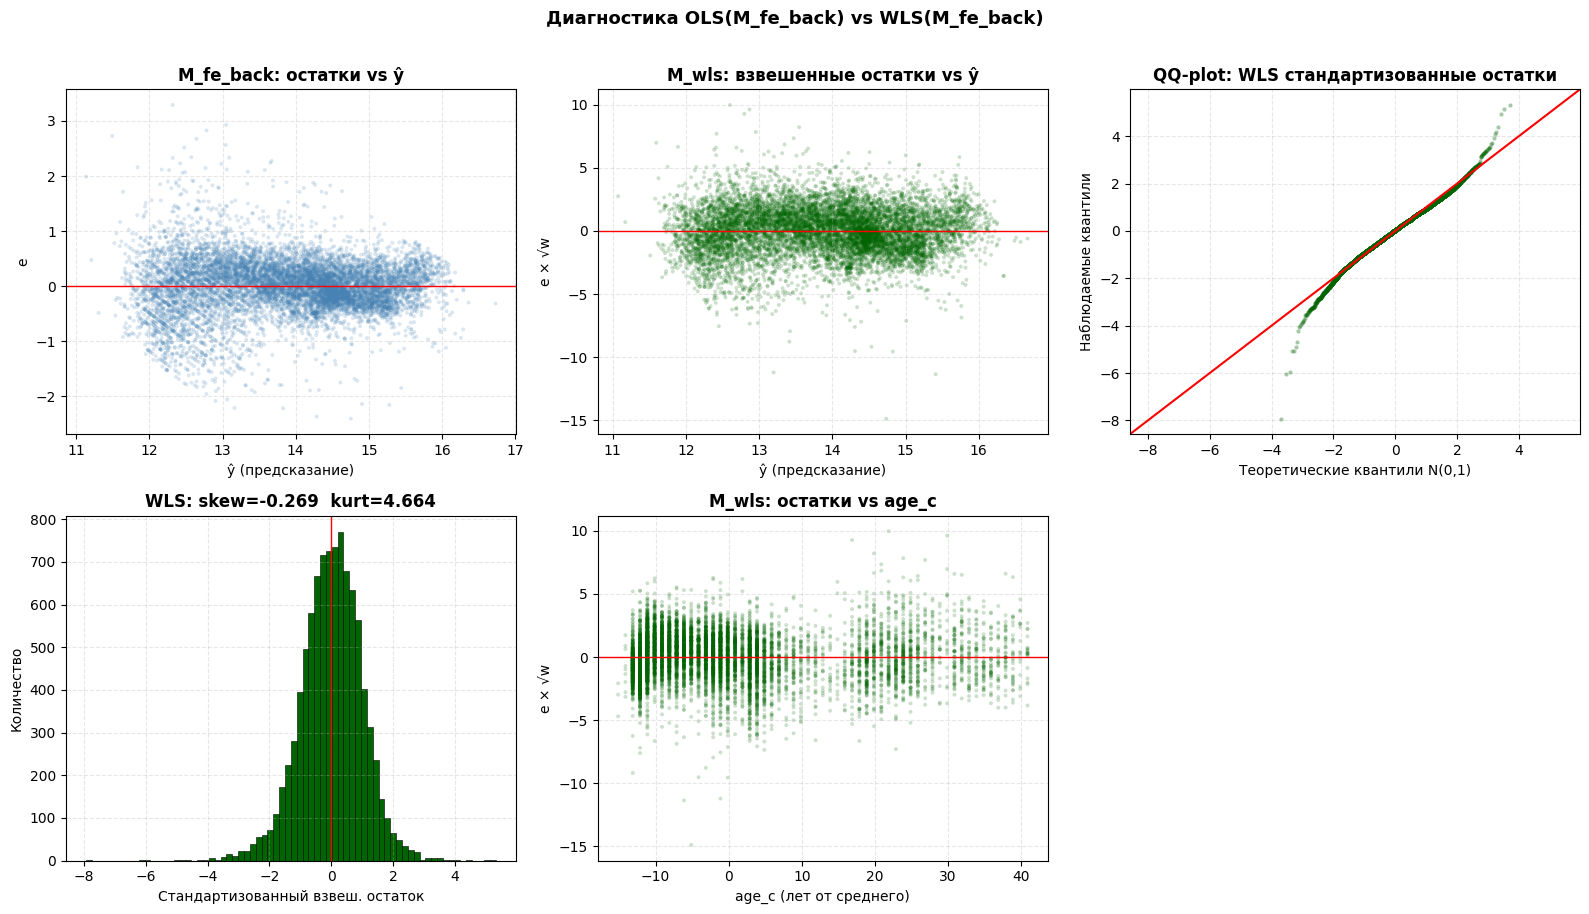

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].scatter(m_fe_back.fittedvalues, m_fe_back.resid, alpha=0.2, s=8,
                  color='steelblue', edgecolors='none')
axes[0,0].axhline(0, color='red', lw=1)
axes[0,0].set_xlabel('ŷ (предсказание)'); axes[0,0].set_ylabel('e')
axes[0,0].set_title('M_fe_back: остатки vs ŷ')

axes[0,1].scatter(m_wls.fittedvalues, wresid, alpha=0.2, s=8,
                  color='darkgreen', edgecolors='none')
axes[0,1].axhline(0, color='red', lw=1)
axes[0,1].set_xlabel('ŷ (предсказание)'); axes[0,1].set_ylabel('e × √w')
axes[0,1].set_title('M_wls: взвешенные остатки vs ŷ')

sr_wls = (wresid - wresid.mean()) / wresid.std()
axes[1,0].hist(sr_wls, bins=70, color='darkgreen', edgecolor='black', linewidth=0.4)
axes[1,0].set_title(f'WLS: skew={stats.skew(sr_wls):.3f}  kurt={stats.kurtosis(sr_wls, fisher=False):.3f}')
axes[1,0].set_xlabel('Стандартизованный взвеш. остаток'); axes[1,0].set_ylabel('Количество')
axes[1,0].axvline(0, color='red', lw=1)

axes[1,1].scatter(df_train['age_c'].iloc[:len(wresid)], wresid, alpha=0.2, s=8,
                  color='darkgreen', edgecolors='none')
axes[1,1].axhline(0, color='red', lw=1)
axes[1,1].set_xlabel('age_c (лет от среднего)'); axes[1,1].set_ylabel('e × √w')
axes[1,1].set_title('M_wls: остатки vs age_c')

sm.qqplot(sr_wls, line='45', ax=axes[0,2], marker='o', markersize=3,
          markerfacecolor='darkgreen', markeredgecolor='none', alpha=0.35)
axes[0,2].set_title('QQ-plot: WLS стандартизованные остатки')
axes[0,2].set_xlabel('Теоретические квантили N(0,1)')
axes[0,2].set_ylabel('Наблюдаемые квантили')

axes[1,2].axis('off')

plt.suptitle('Диагностика OLS(M_fe_back) vs WLS(M_fe_back)', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()



## 8. Сохранение модели WLS


In [9]:
import pickle
with open('wls_model.pkl', 'wb') as fh:
    pickle.dump({
        'base_model': 'M_fe_back',
        'wls_features': list(X_fe_back_c.columns),
        'bp_ols': float(bp_ols[0]),
        'bp_wls': float(bp_wls[0]),
    }, fh)
print('Сохранено: wls_model.pkl')


Сохранено: wls_model.pkl


## Выводы блока 6

**Что улучшилось**:
- BP LM заметно снижается после WLS (считается по факту в ячейках выше)
- `R²adj` у WLS растёт, но это взвешенная шкала — напрямую с OLS сравниваем аккуратно
- стандартные ошибки коэффициентов становятся корректнее для выводов по значимости

**Что остаётся**:
- при большом `n` BP может формально отвергаться даже после улучшения
- часть остаточной неоднородности может быть связана с сегментной структурой данных

→ В блоке 7 проверяем, как сегментация дополняет WLS.
